<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [1]:
# !pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-gpu openpyxl datasets langchain-community ragatouille umap-learn

In [2]:
# !pip install --ignore-installed huggingface-hub==0.20.3

In [3]:
# # После перезапуска ядра
# !pip uninstall huggingface-hub -y
# !pip install huggingface-hub==0.20.3

# # Проверка версии
# import huggingface_hub
# print(f"Installed version: {huggingface_hub.__version__}")

In [4]:
# !pip install --upgrade sentence-transformers

In [5]:
# !pip install pacmap

In [6]:
# !pip install -U bitsandbytes>=0.46.1

In [7]:
# !pip uninstall langchain-community -y
# !pip install langchain-community
# !pip install --upgrade sentence-transformers

In [8]:
# !pip install ragatouille

In [9]:
import warnings

# from huggingface_hub import hf_hub_download
# import huggingface_hub

# huggingface_hub.cached_download = hf_hub_download

warnings.filterwarnings('ignore')

import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain.docstore.document import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, AutoModelForSeq2SeqLM
# from ragatouille import RAGPretrainedModel
import os
import sys

#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки
from langchain.text_splitter import RecursiveCharacterTextSplitter

from sklearn.feature_extraction.text import TfidfVectorizer
import re
import string
import nltk
import pymorphy2
from nltk.corpus import stopwords
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from FlagEmbedding import FlagReranker
import faiss
import gc
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import umap
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from transformers import Pipeline

pd.set_option('display.max_colwidth', 500)
pd.set_option('display.max_rows', 500)

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Используется устройство: {device}')

Используется устройство: cuda


In [11]:
os.makedirs('content', exist_ok=True)
os.makedirs('models', exist_ok=True)

In [12]:
# !nvidia-smi

## Загрузка данных (4 балла)

In [13]:
# url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
# output = 'file.csv'

# gdown.download(url, output, quiet=False)

# data = pd.read_csv('file.csv')

In [14]:
# Загрузка данных

file_id = '1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'content/file.csv'

if not os.path.exists(output):
    gdown.download(id=file_id, output=output, quiet=False)

In [15]:
data = pd.read_csv(output).drop('Unnamed: 0', axis=1, errors='ignore')

In [16]:
# data.sample(500)
data.sample(3)

,Name,WikiData,City,Lon,Lat,description,image,en_txt
11104,Демидовский сад,Q19908952,Ярославль,39.897240,57.625038,Демидовский сад,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBAUGBgUGCA4JCAcHCBEMDQoOFBEVFBMRExMWGB8bFhceFxMTGyUcHiAhIyMjFRomKSYiKR8iIyL/2wBDAQYGBggHCBAJCRAiFhMWIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiL/wAARCAEOAeADASIAAhEBAxEB/8QAHQAAAgMBAQEBAQAAAAAAAAAABQYDBAcCCAEACf/EAEMQAAEDAgUCBQIFAgMHAwMFAAECAwQFEQAGEiExE0EHFCJRYTJxFSNCgZEWoVKxwQgXJDNi0fFy4fAlQ5I1dIKiwv/EABoBAAIDAQEAAAAAAAAAAAAAAAMEAQIFAAb/xAAzEQACAgEEAQMBBgYCAwEAAAABAgADEQQSITFBEyJRBRQyYYGh8CNCcZGxwTPRBhXh8f/aAAwDAQACEQMRAD8A...,there is a statue in the middle of a park with a clock on it
2894,Дом Артистов,Q19615085,Екатеринбург,60.614166,56.839169,здание в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAICAgICAQICAgIDAgIDAwYEAwMDAwcFBQQGCAcJCAgHCAgJCg0LCQoMCggICw8LDA0ODg8OCQsQERAOEQ0ODg7/2wBDAQIDAwMDAwcEBAcOCQgJDg4ODg4ODg4ODg4ODg4ODg4ODg4ODg4ODg4ODg4ODg4ODg4ODg4ODg4ODg4ODg4ODg7/wAARCADIAZADASIAAhEBAxEB/8QAHgAAAQQDAQEBAAAAAAAAAAAABQQGBwgAAwkCAQr/xABKEAACAQMEAAUCAwUEBgcHBQEBAgMEBREABhIhBxMiMUEIFFFhcRUjMoGRCRZCoVJicrHB1BcYGSQzotElNFN2gpLhQ3OjpLTw/8QAHAEAAgIDAQEAAAAAAAAAAAAAAwQCBQABBggH/8QANREAAQQBAwIEBAUDBAMAAAAAAQACAxEEEiExBUETIlGxFDJhcQYVQoGRI6HBUmLR4XKSsv/a...,arafed view of a city with a river and a bridge
5458,Чкаловская лестница,Q4516884,Нижний Новгород,44.009453,56.330479,лестница на Волжском откосе в Нижнем Новгороде,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBAUGBgUGCA4JCAcHCBEMDQoOFBEVFBMRExMWGB8bFhceFxMTGyUcHiAhIyMjFRomKSYiKR8iIyL/2wBDAQYGBggHCBAJCRAiFhMWIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiL/wAARCAEOAeADASIAAhEBAxEB/8QAHAAAAQUBAQEAAAAAAAAAAAAAAwECBAUGBwAI/8QASxAAAgEDAwIEAwUGBAQDBgUFAQIDAAQRBRIhMUEGEyJRFGFxBzKBkaEVI0JSsdFigsHhFiQzkkNy8AglU7LS8RcmY6LiRXODhJT/xAAaAQACAwEBAAAAAAAAAAAAAAABAgADBAUG/8QAMhEAAgIBBAIBAwIEBQUAAAAAAAECEQMEEiExE0EiBRRRMmFScYGRI0KhwfAVM7HR8f/aAAwDAQAC...,nighttime view of a city with a long staircase going up the hill


In [17]:
data['City'].unique()

<ArrowStringArray>
['Екатеринбург', 'Нижний Новгород', 'Владимир', 'Ярославль']
Length: 4, dtype: str

Проверим датасет на предмет пропусков

In [18]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14634 entries, 0 to 14633
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         14634 non-null  str    
 1   WikiData     12078 non-null  str    
 2   City         14634 non-null  str    
 3   Lon          14634 non-null  float64
 4   Lat          14634 non-null  float64
 5   description  12078 non-null  str    
 6   image        14634 non-null  str    
 7   en_txt       14634 non-null  str    
dtypes: float64(2), str(6)
memory usage: 641.0 MB


In [19]:
data.isna().sum()

Name              0
WikiData       2556
City              0
Lon               0
Lat               0
description    2556
image             0
en_txt            0
dtype: int64

Удалим строки с пропусками в WikiData и проверим датасет еще раз на предмет пропусков

In [20]:
data = data.dropna(subset=['WikiData'])

data.isna().sum()

Name           0
WikiData       0
City           0
Lon            0
Lat            0
description    0
image          0
en_txt         0
dtype: int64

In [21]:
# sorted(data['WikiData'].unique(), reverse=True)
# sorted(data['description'].unique(), reverse=False)
sorted(data['en_txt'].unique(), reverse=True)

['прррмомоннннннннннн',
 'yellow house with a black roof and a white fence',
 'yellow flowers in front of a brick building with a clock tower',
 'yellow church with blue domes and a clock tower in a city',
 'yellow church with a golden dome on a sunny day',
 'yellow church with a golden dome on a cloudy day',
 'yellow church with a golden dome and a steeple on a street corner',
 'yellow church with a golden dome and a cross on top',
 'yellow church with a blue dome and a cross on the front',
 'yellow bus parked in front of a large yellow building with a green roof',
 'yellow building with white trim and windows on a sunny day',
 'yellow building with white trim and windows on a street corner',
 'yellow building with white trim and windows in winter time',
 'yellow building with white trim and windows in snow covered area',
 'yellow building with white trim and windows and a sign on the front',
 'yellow building with white trim and windows',
 'yellow building with white trim and columns

In [22]:
# В колонке 'en_txt' замечено значение 'прррмомоннннннннннн', заменим его на моду

mask = data['en_txt'] == 'прррмомоннннннннннн'
name_field = data[mask]['Name'].iloc[0]
print(name_field)

mode_value = data[data['Name'] == name_field]['en_txt'].mode()[0]
print(mode_value)

data.loc[mask, 'en_txt'] = mode_value

Ярославский дворец молодёжи
there is a building with a sign on the top of it


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [23]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [24]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

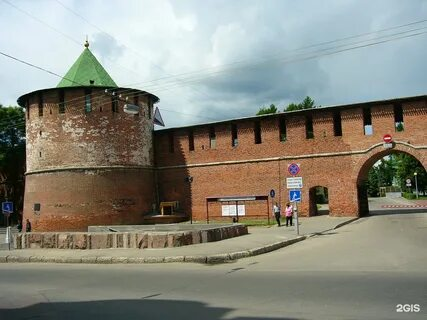

In [25]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - самое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

Проверим датасет на предмет пропусков

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

Вместо RAGatouille из ragatouille буду использорвать альтернативу (CrossEncoderReranker)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

tfidf = TfidfVectorizer(max_features=50, stop_words=['the', 'a', 'an', 'is', 'are', 'there'])
tfidf_matrix = tfidf.fit_transform(data['en_txt'].fillna(''))

avg_tfidf = np.array(tfidf_matrix.mean(axis=1)).flatten()
data['tfidf_score'] = avg_tfidf

threshold = np.percentile(avg_tfidf, 95)
data['is_outlier'] = data['tfidf_score'] > threshold

clean_data = data[~data['is_outlier']].copy()

# Альтернативный подход: создаём уникальный ключ и группируем вручную
clean_data['group_key'] = clean_data['City'].astype(str) + '||' + clean_data['Name'].astype(str)

# Выбираем по одному случайному образцу из каждой группы
stratified_data = clean_data.groupby('group_key', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 1), random_state=42)
).reset_index(drop=True)

# Проверяем, есть ли столбец group_key перед удалением
if 'group_key' in stratified_data.columns:
    stratified_data = stratified_data.drop(columns=['group_key'])
else:
    print("Столбец 'group_key' уже был удалён")

print(f'После стратификации: {len(stratified_data)} уникальных мест')
print(f'Сохранились столбцы: {stratified_data.columns.tolist()}')

# Проверяем наличие City перед выводом
if 'City' in stratified_data.columns:
    print(f'Распределение по городам:')
    print(stratified_data["City"].value_counts())
else:
    print("ВНИМАНИЕ: столбец 'City' отсутствует в данных")
    print(f"Доступные столбцы: {stratified_data.columns.tolist()}")

# Ограничиваем до 100 записей
if len(stratified_data) > 100:
    stratified_data = stratified_data.sample(n=100, random_state=42)

# Создаём best_description - выбираем самое длинное описание для каждого названия
if 'en_txt' in stratified_data.columns and 'Name' in stratified_data.columns:
    stratified_data['desc_length'] = stratified_data['en_txt'].fillna('').astype(str).str.len()
    stratified_data = stratified_data.sort_values('desc_length', ascending=False)
    stratified_data = stratified_data.drop_duplicates(subset=["Name"], keep='first')
    stratified_data = stratified_data.drop(columns=['desc_length'])
else:
    print(f"Не хватает столбцов: en_txt={'en_txt' in stratified_data.columns}, Name={'Name' in stratified_data.columns}")

# Создание обогащённого текста
if 'Name' in stratified_data.columns and 'City' in stratified_data.columns and 'description' in stratified_data.columns:
    english_col = 'en_txt' if 'en_txt' in stratified_data.columns else 'englishText'
    
    stratified_data['fullText'] = (
        stratified_data["Name"].fillna('').astype(str) + '. ' +
        stratified_data["City"].fillna('').astype(str) + '. ' +
        stratified_data['description'].fillna('').astype(str) + ' ' +
        stratified_data[english_col].fillna('').astype(str)
    )
    
    stratified_data['fullText'] = stratified_data['fullText'].str.replace(r'\s+', ' ', regex=True).str.strip()
else:
    print("Не удалось создать fullText: отсутствуют необходимые столбцы")

print(f"Чистых записей: {len(clean_data)}")
print(f"Удалено выбросов: {data['is_outlier'].sum()}")
print(f"Итоговый размер sample: {len(stratified_data)}")

if 'Name' in stratified_data.columns and 'City' in stratified_data.columns and 'fullText' in stratified_data.columns:
    print(f"\nПример данных:\n{stratified_data[['Name', 'City', 'fullText']].head()}")
elif 'Name' in stratified_data.columns and 'City' in stratified_data.columns:
    print(f"\nПример данных (без fullText):\n{stratified_data[['Name', 'City', 'en_txt']].head()}")
else:
    print(f"\nПервые строки данных:\n{stratified_data.head()}")

Столбец 'group_key' уже был удалён
После стратификации: 320 уникальных мест
Сохранились столбцы: ['Name', 'WikiData', 'City', 'Lon', 'Lat', 'description', 'image', 'en_txt', 'tfidf_score', 'is_outlier']
Распределение по городам:
City
Нижний Новгород    98
Екатеринбург       97
Ярославль          96
Владимир           29
Name: count, dtype: int64
Чистых записей: 11474
Удалено выбросов: 604
Итоговый размер sample: 100

Пример данных:
                                          Name             City  \
78                       Площадь 1-й Пятилетки     Екатеринбург   
167                                 Лицей № 82  Нижний Новгород   
146              Дом Ермолаевых — П. Парфёнова  Нижний Новгород   
119  №18 Фотографический музей «Дом Метенкова»     Екатеринбург   
63                             Комсомолу Урала     Екатеринбург   

                                                                                                                                                      fullText  


In [28]:
# Настройка сплиттера текста
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=512,
    chunk_overlap=100,
    separators=['\n\n', '\n', '. ', ' ', ''],
    length_function=len
)

document_texts = stratified_data['fullText'].tolist()
document_metadata = stratified_data[['Name', 'City', 'description']].to_dict('records')

# Создание чанков
all_chunks = []
all_metadata = []

for text_index, current_text in enumerate(document_texts):
    if isinstance(current_text, str) and len(current_text) > 10:
        chunks = text_splitter.split_text(current_text)

        for text_chunk in chunks:
            all_chunks.append(text_chunk)
            all_metadata.append(document_metadata[text_index])

print(f'Создано {len(all_chunks)} чанков из {len(document_texts)} документов')

# Загрузка модели эмбеддингов
embedding_model = SentenceTransformer('intfloat/multilingual-e5-small')
embedding_model = embedding_model.to(device)
embedding_model.eval()
print('Модель эмбеддингов загружена')

# Создание эмбеддингов
chunk_embeddings = embedding_model.encode(
    all_chunks,
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=32
)
print(f'Эмбеддинги созданы, форма: {chunk_embeddings.shape}')

faiss_index = faiss.IndexFlatIP(chunk_embeddings.shape[1])
faiss_index.add(chunk_embeddings.astype('float32'))
print(f'Векторная база данных создана, размерность: {faiss_index.d}')

Создано 100 чанков из 100 документов
Модель эмбеддингов загружена


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Эмбеддинги созданы, форма: (100, 384)
Векторная база данных создана, размерность: 384


In [29]:
def search_chunks_by_query(search_query, results_number=10):
    query_embedding = embedding_model.encode([search_query], normalize_embeddings=True)
    distance_scores, found_indices = faiss_index.search(query_embedding.astype('float32'), results_number)
    search_results = []

    for result_index, score_value in zip(found_indices[0], distance_scores[0]):
        search_results.append({
            'text': all_chunks[result_index],
            'metaData': all_metadata[result_index],
            'score': float(score_value)
        })

    return search_results

In [30]:
reranker_model = FlagReranker('BAAI/bge-reranker-large', use_fp16=True)
print('Модель переранжировщика загружена')

Модель переранжировщика загружена


In [31]:
# Отключаем прогресс-бары
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'

# Временно перенаправляем потоки вывода
original_stdout = sys.stdout
original_stderr = sys.stderr
sys.stdout = open(os.devnull, 'w')
sys.stderr = open(os.devnull, 'w')

try:
    reader_model_name = 'google/flan-t5-base'
    reader_tokenizer = AutoTokenizer.from_pretrained(reader_model_name)
    reader_model = AutoModelForSeq2SeqLM.from_pretrained(
        reader_model_name,
        device_map='auto',
        torch_dtype=torch.float32
    )
    reader_pipeline = pipeline(
        'text2text-generation',
        model=reader_model,
        tokenizer=reader_tokenizer,
        max_new_tokens=200,
        do_sample=False
    )
finally:
    # Восстанавливаем вывод
    sys.stdout.close()
    sys.stderr.close()
    sys.stdout = original_stdout
    sys.stderr = original_stderr

print('Модель для генерации ответов загружена')

Device set to use cuda:0


Модель для генерации ответов загружена


Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

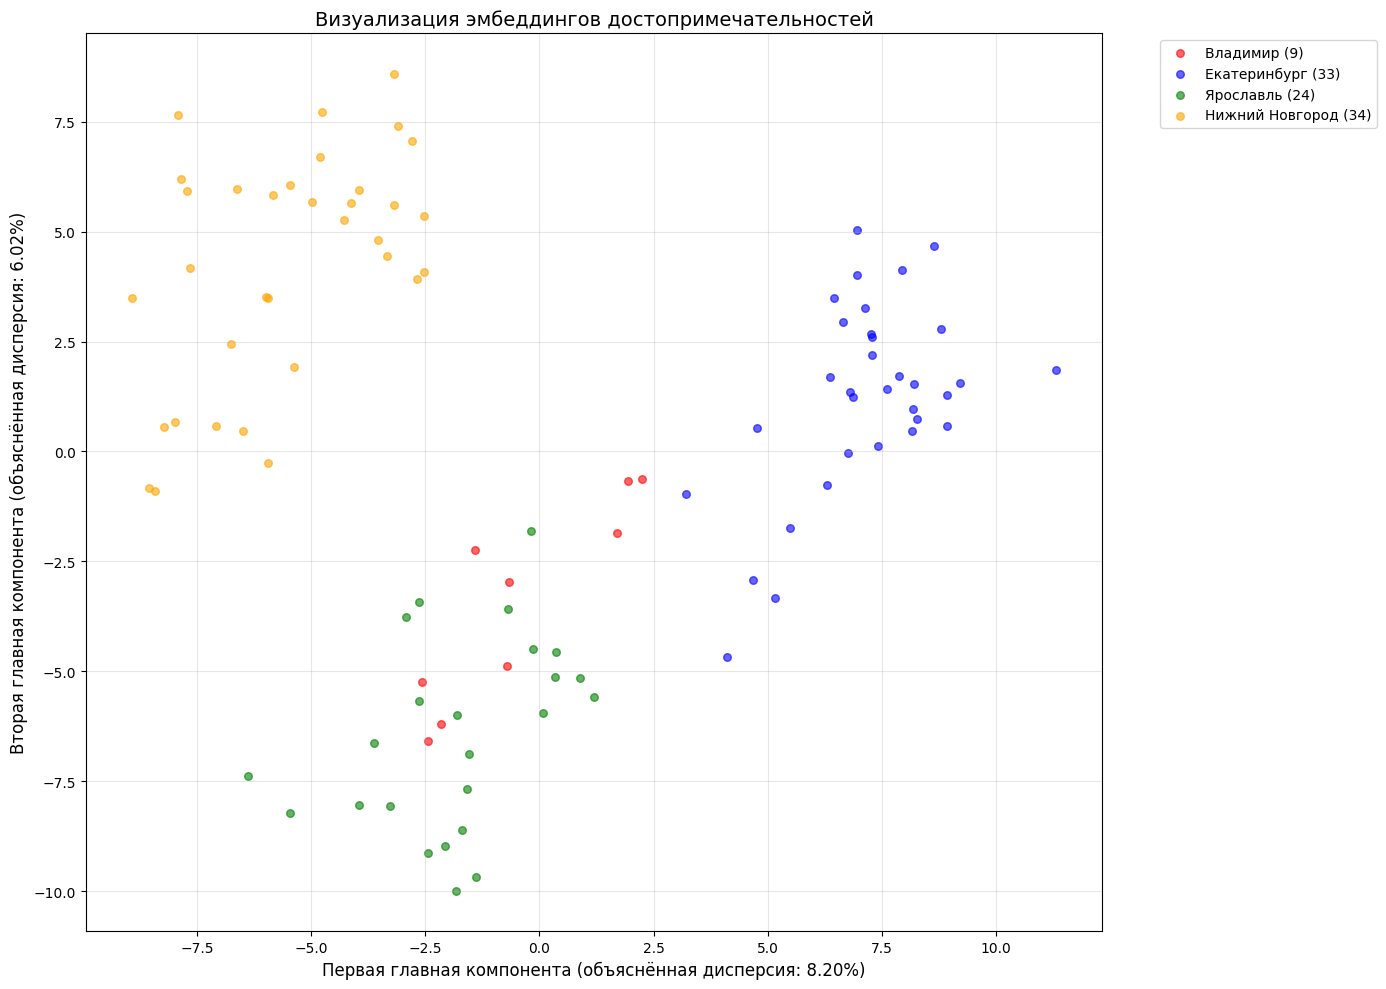

In [32]:
# Берём строки с городами
has_city = stratified_data["City"].notna()
cities_data = stratified_data[has_city].copy()

# Если записей с городами достаточно, используем их все
sample_size = min(2000, len(cities_data))
sample_data = cities_data.sample(sample_size, random_state=42).copy()

# Создаём эмбеддинги
sample_embeddings = np.array(embedding_model.encode(
    sample_data['fullText'].fillna('').tolist(),
    normalize_embeddings=False,
    show_progress_bar=True
))

# Берём города
city_names = sample_data["City"].tolist()

# Нормализация
scaler = StandardScaler()
sample_embeddings_scaled = scaler.fit_transform(sample_embeddings)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(sample_embeddings_scaled)

explained_variance = pca.explained_variance_ratio_

# Визуализация
plt.figure(figsize=(14, 10))

known_cities = list(set(city_names))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for index, city in enumerate(known_cities):
    mask = [item == city for item in city_names]

    if sum(mask) > 0:
        plt.scatter(
            pca_result[mask, 0],
            pca_result[mask, 1],
            label=f'{city} ({sum(mask)})',
            alpha=0.6,
            s=30,
            color=colors[index % len(colors)]
        )

plt.title('Визуализация эмбеддингов достопримечательностей', fontsize=14)
plt.xlabel(f'Первая главная компонента (объяснённая дисперсия: {explained_variance[0]:.2%})', fontsize=12)
plt.ylabel(f'Вторая главная компонента (объяснённая дисперсия: {explained_variance[1]:.2%})', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [33]:
sil_score_pca = silhouette_score(sample_embeddings_scaled, [known_cities.index(city) for city in city_names if city in known_cities[:len(colors)]])
print(f'Коэффициент силуэта: {sil_score_pca:.4f}')

Коэффициент силуэта: 0.0815


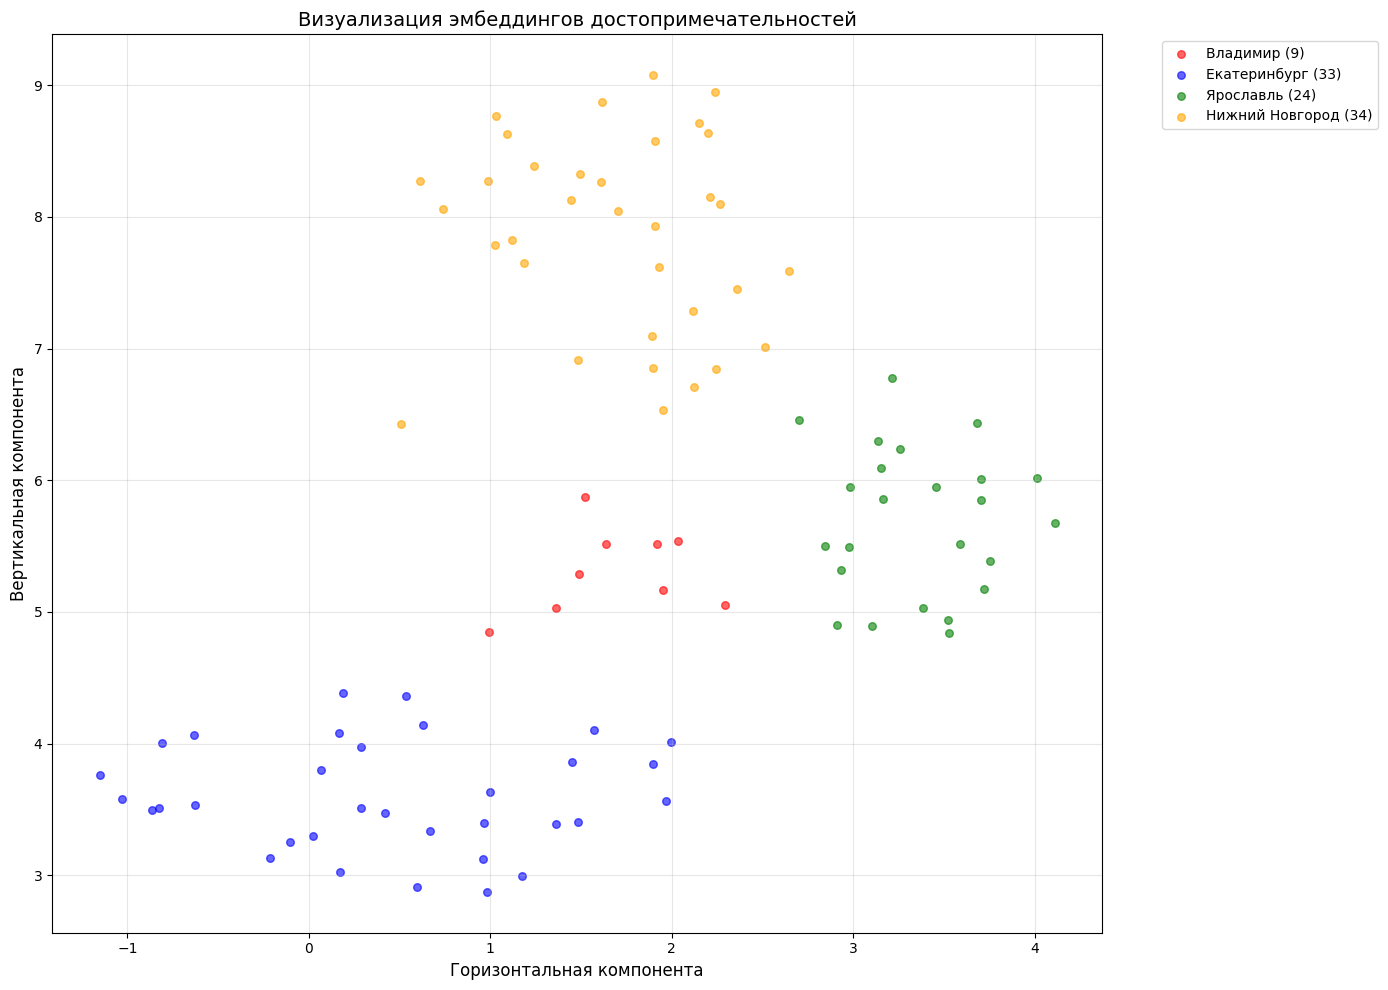

In [34]:
# Нормализация
scaler = MinMaxScaler()
sample_embeddings = scaler.fit_transform(sample_embeddings)

# Уменьшение размерности
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)
umap_result = umap_reducer.fit_transform(sample_embeddings)

# Визуализация
plt.figure(figsize=(14, 10))

known_cities = list(set(city_names))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for index, city in enumerate(known_cities):
    mask = [item == city for item in city_names]

    if sum(mask) > 0:
        plt.scatter(
            umap_result[mask, 0],
            umap_result[mask, 1],
            label=f'{city} ({sum(mask)})',
            alpha=0.6,
            s=30,
            color=colors[index % len(colors)]
        )

plt.title('Визуализация эмбеддингов достопримечательностей', fontsize=14)
plt.xlabel('Горизонтальная компонента', fontsize=12)
plt.ylabel('Вертикальная компонента', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# НУЖНО РЕАЛИЗВАТЬ!!!

In [36]:
# from sklearn.decomposition import PCA
# import umap
# import matplotlib.pyplot as plt
# import numpy as np

# embeddings_matrix = np.array([embeddings.embed_query(doc.page_content) for doc in documents])

# pca = PCA(n_components=2)
# embeddings_pca = pca.fit_transform(embeddings_matrix)

# umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
# embeddings_umap = umap_reducer.fit_transform(embeddings_matrix)

# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# axes[0].scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], alpha=0.7, s=30)
# axes[0].set_title(f'PCA (explained variance: {pca.explained_variance_ratio_.sum():.2%})')
# axes[0].set_xlabel('PC1')
# axes[0].set_ylabel('PC2')

# scatter = axes[1].scatter(embeddings_umap[:, 0], embeddings_umap[:, 1],
#                           c=range(len(documents)), cmap='viridis', alpha=0.7, s=30)
# axes[1].set_title('UMAP projection')
# axes[1].set_xlabel('UMAP1')
# axes[1].set_ylabel('UMAP2')
# plt.colorbar(scatter, ax=axes[1], label='Document index')

# plt.tight_layout()
# plt.show()

# print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [37]:
def rag_query(question, top_k_retrieve=10, top_k_final=3):
    if not isinstance(question, str) or len(question.strip()) == 0:
        return 'Информация не найдена', []

    # Поиск релевантных чанков
    retrieved = search_chunks_by_query(question, results_number=top_k_retrieve)
    retrieved_texts = [item['text'] for item in retrieved]
    retrieved_metadata = [item['metaData'] for item in retrieved]

    # Ранжирование через FlagReranker
    pairs = [[question, text] for text in retrieved_texts]
    scores = reranker_model.compute_score(pairs)

    # Сортировка по убыванию релевантности
    scored = list(zip(retrieved_texts, retrieved_metadata, scores))
    scored.sort(key=lambda x: x[2], reverse=True)

    # Берём отсортированные данные
    final_results = scored[:top_k_final]
    final_metadata = [item[1] for item in final_results]
    final_texts = [item[0] for item in final_results]

    # Возвращаем первый найденный контекст как ответ
    if final_metadata:
        item = final_metadata[0]
        # Безопасное получение полей с проверкой на NaN
        name = item.get("Name", '')
        city = item.get("City", '')
        description = item.get('description', '')

        # Проверка на NaN и преобразование в строку
        if pd.isna(name):
            name = ''

        if pd.isna(city):
            city = ''

        if pd.isna(description):
            description = ''

        # Преобразуем в строку и обрезаем
        name = str(name)
        city = str(city)
        description = str(description)[:200]

        answer = f'{name}. {city}. {description}'
    else:
        answer = 'Информация не найдена'

    return answer, final_texts

In [38]:
def data_preprocess(data, sample_size=50):
    sampled_data = data.sample(min(sample_size, len(data)), random_state=42)
    evaluation_data = []

    for _, row in tqdm(sampled_data.iterrows(), total=len(sampled_data), desc='Обработка'):
        try:
            if pd.isna(row["Name"]) or pd.isna(row["City"]):
                continue

            city_name = row["City"]
            question = f'Опишите {row["Name"]} в городе {city_name}'
            answer, contexts = rag_query(question)

            # Проверка, что контексты не пустые
            if not contexts:
                print(f'Нет контекстов для {row["Name"]}')

                continue

            evaluation_data.append({
                'question': question,
                'answer': answer,
                'contexts': contexts,
                'groundTruths': row['description']
            })
        except Exception as error:
            print(f'Ошибка при обработке {row["Name"]}: {error}')

            continue

    evaluation_data = pd.DataFrame(evaluation_data)
    print(f'Подготовлено {len(evaluation_data)} примеров для оценки')

    return evaluation_data

In [39]:
def answer_relevancy(question, answer, embedding_model, generated_questions=3):
    if not isinstance(question, str) or not isinstance(answer, str):
        return {'answerRelevancy': 0.0, 'directSimilarity': 0.0, 'generatedSimilarity': 0.0, 'generatedQuestions': 0}

    if len(question.strip()) == 0 or len(answer.strip()) == 0:
        return {'answerRelevancy': 0.0, 'directSimilarity': 0.0, 'generatedSimilarity': 0.0, 'generatedQuestions': 0}

    # Эмбеддинг исходного вопроса
    question_embedding = embedding_model.encode([question], normalize_embeddings=True)[0]

    # Разбиваем ответ на предложения для генерации обратных вопросов
    answer_sentences = answer.split('. ')
    generated_questions_list = []

    # Генерируем обратные вопросы на основе ключевых слов из ответа
    for sentence in answer_sentences[:generated_questions]:
        if len(sentence) > 20:  # Берем только достаточно длинные предложения
            # Извлекаем ключевые слова (первые 5 слов предложения)
            key_words = sentence.split()[:5]

            if key_words:
                generated_question = f'Что такое {" ".join(key_words)}?'
                generated_questions_list.append(generated_question)

    # Если не удалось сгенерировать вопросы, используем исходный вопрос
    if not generated_questions_list:
        generated_questions_list = [question]

    # Вычисляем косинусное сходство между исходным вопросом и сгенерированными вопросами
    similarity_scores = []

    for generated_question in generated_questions_list:
        generated_question_embedding = embedding_model.encode([generated_question], normalize_embeddings=True)[0]
        similarity_score = float(np.dot(question_embedding, generated_question_embedding))
        similarity_scores.append(similarity_score)

    # Вычисляем прямое сходство между вопросом и ответом
    answer_embedding = embedding_model.encode([answer], normalize_embeddings=True)[0]
    direct_similarity_score = float(np.dot(question_embedding, answer_embedding))

    # Итоговый score (среднее арифметическое прямого и обратного сходства)
    final_relevancy_score = (direct_similarity_score + np.mean(similarity_scores)) / 2

    return {
        'answerRelevancy': final_relevancy_score,
        'directSimilarity': direct_similarity_score,
        'generatedSimilarity': np.mean(similarity_scores),
        'generatedQuestions': len(generated_questions_list)
    }

In [40]:
# Создание датасета для оценки
sample_size = min(50, len(stratified_data))
evaluation_dataset = data_preprocess(stratified_data, sample_size=sample_size)

# Вычисление релевантности ответа для всех примеров
relevancy_scores = []

for index, row in evaluation_dataset.iterrows():
    relevancy_result = answer_relevancy(
        row['question'],
        row['answer'],
        embedding_model
    )
    relevancy_scores.append(relevancy_result['answerRelevancy'])

    if index % 10 == 0:
        print(f'Обработано {index} из {len(evaluation_dataset)} примеров')

print(f'Релевантность ответа: {np.mean(relevancy_scores):.4f}')
print(f'Стандартное отклонение: {np.std(relevancy_scores):.4f}')

Обработка:   0%|          | 0/50 [00:00<?, ?it/s]

You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Подготовлено 50 примеров для оценки
Обработано 0 из 50 примеров
Обработано 10 из 50 примеров
Обработано 20 из 50 примеров
Обработано 30 из 50 примеров
Обработано 40 из 50 примеров
Релевантность ответа: 0.9319
Стандартное отклонение: 0.0260


# Протестируйте ваш RAG (3 балла)

In [41]:
testing_questions = [
    'Какие музеи есть в Екатеринбурге?',
    'Где находится Дом-музей Бажова?',
    'Что можно посмотреть в Харитоновском саду?',
    'Где находится Свято-Троицкий кафедральный собор?',
    'Какие театры есть в Екатеринбурге?',
    'Где находится Суворовское училище?',
    'Что представляет собой Художественный музей Эрнста Неизвестного?',
    'Где находится памятник Серго Орджоникидзе?',
    'Какие исторические здания есть в Екатеринбурге?',
    'Где находится Дом обороны?',
    'Какие памятники архитектуры есть в центре Екатеринбурга?',
    'Где находится Театр кукол в Екатеринбурге?',
    'Что можно увидеть в Литературной жизни Урала XX века?',
    'Где находится Храм Вознесения Господня?',
    'Какие достопримечательности есть в районе Плотинки?',
    'Где находится Дом-музей Мамина-Сибиряка?',
    'Что находится на площади 1905 года?',
    'Где расположен памятник Татищеву и де Геннину?',
    'Какие православные храмы есть в Екатеринбурге?',
    'Где находится Уральский геологический музей?',
    'Что находится в Екатеринбургском музее изобразительных искусств?',
    'Где находится Царский мост?',
    'Какие памятники есть в Екатеринбурге?',
    'Где находится Дом Севастьянова?',
    'Что можно увидеть в Уральской государственной консерватории?',
    'Где находится Ново-Тихвинский монастырь?',
    'Какие достопримечательности есть во Владимире?',
    'Где находятся Золотые ворота?',
    'Что такое Белокаменные памятники Владимира и Суздаля?',
    'Где находится Дмитриевский собор?',
    'Какие церкви есть во Владимире?',
    'Где находится Богородице-Рождественский монастырь?',
    'Что можно увидеть в Троицкой церкви Владимира?',
    'Где находится Собор Успения Пресвятой Богородицы?',
    'Какие музеи есть в Ярославле?',
    'Где находится Демидовский столп?',
    'Что можно посмотреть в Ярославском музее-заповеднике?',
    'Где находится Церковь Ильи Пророка?',
    'Какие театры есть в Ярославле?',
    'Где находится Спасо-Преображенский монастырь?',
    'Какие достопримечательности есть в Нижнем Новгороде?',
    'Где находится Нижегородский кремль?',
    'Что представляет собой Чкаловская лестница?',
    'Где находится Церковь Рождества Иоанна Предтечи?',
    'Какие музеи есть в Нижнем Новгороде?',
    'Где находится памятник Минину и Пожарскому?',
    'Что можно увидеть в Нижегородском речном училище?',
    'Где находится Благовещенский монастырь?',
    'Какие храмы есть в Нижнем Новгороде?',
    'Где находится Крестовоздвиженский собор?'
]

scores = []

print('\n' + '=' * 100)
print('Тестирование RAG системы')
print('=' * 100)

for question in testing_questions:
    print(f'Вопрос: {question}')
    answer, contexts = rag_query(question)
    print(f'Ответ: {answer[:500]}')
    print(f'Использовано контекстов: {len(contexts)}')
    print('-' * 50)


Тестирование RAG системы
Вопрос: Какие музеи есть в Екатеринбурге?
Ответ: Музей кукол и детской книги «Страна чудес». Екатеринбург. Музей кукол и детской книги «Страна чудес»
Использовано контекстов: 3
--------------------------------------------------
Вопрос: Где находится Дом-музей Бажова?
Ответ: Усадьба Е. И. Богоявленской. Нижний Новгород. Усадьба Е. И. Богоявленской
Использовано контекстов: 3
--------------------------------------------------
Вопрос: Что можно посмотреть в Харитоновском саду?
Ответ: Нижегородский государственный художественный музей. Нижний Новгород. один из старейших музеев России, крупнейший музей изобразительного искусства в Нижегородской области.
Использовано контекстов: 3
--------------------------------------------------
Вопрос: Где находится Свято-Троицкий кафедральный собор?
Ответ: Старообрядческий храм Иоанна Златоуста в Коровниках. Ярославль. Православный храм в Ярославле
Использовано контекстов: 3
--------------------------------------------------
Вопр

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [42]:
# Метрика точности контекста
def context_precision(question, contexts, embedding_model, threshold=0.7):
    question_embedding = embedding_model.encode([question], normalize_embeddings=True)[0]
    relevant_count = 0
    precision_sum = 0

    for index, context in enumerate(contexts, 1):
        context_embedding = embedding_model.encode([context], normalize_embeddings=True)[0]
        similarity = float(np.dot(question_embedding, context_embedding))

        if similarity > threshold:
            relevant_count += 1

        precision_sum += relevant_count / index

    return precision_sum / len(contexts) if contexts else 0.0

# Вычисление точности контекста для всех примеров
precision_scores = []

for _, row in evaluation_dataset.iterrows():
    # Проверка на валидность данных
    if not isinstance(row['question'], str) or not isinstance(row['contexts'], list):
        continue

    if len(row['contexts']) == 0:
        continue

    score = context_precision(row['question'], row['contexts'], embedding_model)
    precision_scores.append(score)

print(f'Точность контекста: {np.mean(precision_scores):.4f}')
print(f'Стандартное отклонение: {np.std(precision_scores):.4f}')
print(f'Минимальное значение: {np.min(precision_scores):.4f}')
print(f'Максимальное значение: {np.max(precision_scores):.4f}')

Точность контекста: 1.0000
Стандартное отклонение: 0.0000
Минимальное значение: 1.0000
Максимальное значение: 1.0000


In [43]:
# Метрика полнота контекста
def context_recall(ground_truth, contexts, embedding_model, threshold=0.5):
    if ground_truth is None or pd.isna(ground_truth):
        return 0.0

    if not isinstance(ground_truth, str):
        return 0.0

    if not contexts:
        return 0.0

    ground_truth_embedding = embedding_model.encode([ground_truth], normalize_embeddings=True)[0]
    context_embeddings = embedding_model.encode(contexts, normalize_embeddings=True)

    similarities = [float(np.dot(ground_truth_embedding, context_embedding)) for context_embedding in context_embeddings]

    relevant = sum(1 for similarity in similarities if similarity > threshold)

    return relevant / len(contexts) if contexts else 0.0

# Вычисление полнота контекста для всех примеров
recall_scores = []

for _, row in evaluation_dataset.iterrows():
    if pd.isna(row['groundTruths']) or not isinstance(row['groundTruths'], str):
        continue

    score = context_recall(row['groundTruths'], row['contexts'], embedding_model)
    recall_scores.append(score)

print(f'Полнота контекста: {np.mean(recall_scores):.4f}')
print(f'Стандартное отклонение: {np.std(recall_scores):.4f}')
print(f'Минимальное значение: {np.min(recall_scores):.4f}')
print(f'Максимальное значение: {np.max(recall_scores):.4f}')

Полнота контекста: 1.0000
Стандартное отклонение: 0.0000
Минимальное значение: 1.0000
Максимальное значение: 1.0000
